https://www.kaggle.com/datasets/lovishbansal123/nasa-asteroids-classification

Maxwell Colburn

Nicholas Garcia

In [ ]:
import xgboost as xgb  # XGBoost library for gradient boosting
from sklearn.datasets import load_iris  # Built-in iris dataset
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.metrics import accuracy_score, classification_report  # For evaluation
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("nasa.csv")

In [ ]:
df

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.600,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.300,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.300,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.400,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.600,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4682,3759007,3759007,23.900,0.044112,0.098637,44.111820,98.637028,0.027410,0.061290,144.723824,...,164.183305,457.179984,0.741558,276.395697,1.581299,2.457708e+06,304.306025,0.787436,J2000,False
4683,3759295,3759295,28.200,0.006089,0.013616,6.089126,13.615700,0.003784,0.008460,19.977449,...,345.225230,407.185767,0.996434,42.111064,1.153835,2.458088e+06,282.978786,0.884117,J2000,False
4684,3759714,3759714,22.700,0.076658,0.171412,76.657557,171.411509,0.047633,0.106510,251.501180,...,37.026468,690.054279,0.965760,274.692712,2.090708,2.458300e+06,203.501147,0.521698,J2000,False
4685,3759720,3759720,21.800,0.116026,0.259442,116.025908,259.441818,0.072095,0.161210,380.662441,...,163.802910,662.048343,1.185467,180.346090,1.787733,2.458288e+06,203.524965,0.543767,J2000,False


In [ ]:
df = df.drop("Neo Reference ID", axis=1)

In [ ]:
df = df.drop("Name", axis=1)

In [ ]:
df = df.drop("Equinox", axis=1)

In [ ]:
df = df.drop("Close Approach Date", axis=1, errors='ignore')
df = df.drop("Epoch Date Close Approach", axis=1, errors='ignore')

In [ ]:
df

,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),Est Dia in Feet(max),Relative Velocity km per sec,...,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Hazardous
0,21.600,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,933.308089,6.115834,...,6.025981,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,True
1,21.300,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,1071.581063,18.113985,...,28.412996,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,False
2,20.300,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,1698.341531,7.590711,...,4.237961,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,True
3,27.400,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,64.569144,11.173874,...,7.905894,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,False
4,21.600,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,933.308089,9.840831,...,16.793382,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4682,23.900,0.044112,0.098637,44.111820,98.637028,0.027410,0.061290,144.723824,323.612307,22.154265,...,39.880491,164.183305,457.179984,0.741558,276.395697,1.581299,2.457708e+06,304.306025,0.787436,False
4683,28.200,0.006089,0.013616,6.089126,13.615700,0.003784,0.008460,19.977449,44.670934,3.225150,...,5.360249,345.225230,407.185767,0.996434,42.111064,1.153835,2.458088e+06,282.978786,0.884117,False
4684,22.700,0.076658,0.171412,76.657557,171.411509,0.047633,0.106510,251.501180,562.373736,7.191642,...,4.405467,37.026468,690.054279,0.965760,274.692712,2.090708,2.458300e+06,203.501147,0.521698,False
4685,21.800,0.116026,0.259442,116.025908,259.441818,0.072095,0.161210,380.662441,851.187094,11.352090,...,21.080244,163.802910,662.048343,1.185467,180.346090,1.787733,2.458288e+06,203.524965,0.543767,False


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
label = le.fit_transform(df['Hazardous'])
label
#convert categorical column to numerical

array([1, 0, 1, ..., 0, 0, 0])

In [ ]:
x = df.drop("Hazardous",axis=1)
y = df["Hazardous"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.3,  # 30% for testing
    random_state=42,  # Random seed for reproducibility
    stratify=y  # Maintain class proportions in both sets
)

In [ ]:
model = xgb.XGBClassifier(
    max_depth=3,           # Maximum depth of each tree (shallow trees = simpler model)
    n_estimators=50,       # Number of boosting rounds (trees to build)
    learning_rate=0.1,     # Step size shrinkage (lower = more conservative)
    objective='binary:logistic',  # Binary classification with probability output
    random_state=42,       # For reproducibility
    eval_metric='logloss'  # Evaluation metric during training
)

In [ ]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
#predict on training data
y_train_pred = model.predict(X_train)
#predict on test data
y_test_pred = model.predict(X_test)
#probability predictions
y_test_probe = model.predict_proba(X_test)


#accuracy score
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy on test set: {accuracy:.4f}")

Accuracy on test set: 0.9957


In [ ]:
import pandas as pd
import numpy as np

# get feature names from the training data
feature_names = X_train.columns.tolist()

# collect input data using simple input()
new_data_values = []
print("Please enter values for the following features:")
for feature in feature_names:
    while True:
        try:
            value = float(input(f"{feature}: "))
            new_data_values.append(value)
            break
        except ValueError:
            print("Invalid input. Please enter a numerical value.")

# create a DataFrame for the new data point
new_data_df = pd.DataFrame([new_data_values], columns=feature_names)

# make prediction
prediction = model.predict(new_data_df)
prediction_proba = model.predict_proba(new_data_df)

# decode prediction (True for Hazardous, False for Not Hazardous)
predicted_class = "Hazardous" if prediction[0] else "Not Hazardous"

# get probabilities for each class
proba_hazardous = prediction_proba[0][1] # Probability of being Hazardous
proba_not_hazardous = prediction_proba[0][0] # Probability of being Not Hazardous

print(f"\nPredicted Status: {predicted_class}")
print(f"Probability of being Hazardous: {proba_hazardous:.4f}")
print(f"Probability of not being Hazardous: {proba_not_hazardous:.4f}")

Please enter values for the following features:
Absolute Magnitude: 21
Est Dia in KM(min): .12
Est Dia in KM(max): .32
Est Dia in M(min): 319
Est Dia in M(max): 517
Est Dia in Miles(min): .45
Est Dia in Miles(max): .17
Est Dia in Feet(min): 417
Est Dia in Feet(max): 933
Epoch Date Close Approach: 10
Relative Velocity km per sec: 35426
Relative Velocity km per hr: 22012
Miles per hour: .28
Miss Dist.(Astronomical): 20
Miss Dist.(lunar): 61010824
Miss Dist.(kilometers): 38923213
Miss Dist.(miles): 26552369
Orbit ID: 100
Orbit Uncertainity: 6
Minimum Orbit Intersection: .005
Jupiter Tisserand Invariant: 5
Epoch Osculation: 24580000
Eccentricity: .45
Semi Major Axis: 1.4
Inclination: 28
Asc Node Longitude: 314
Orbital Period: 609
Perihelion Distance: .808258
Perihelion Arg: 313
Aphelion Dist: 3
Perihelion Time: 234814
Mean Anomaly: 263.82
Mean Motion: .6

Predicted Status: Hazardous
Probability of being Hazardous: 0.9873
Probability of not being Hazardous: 0.0127


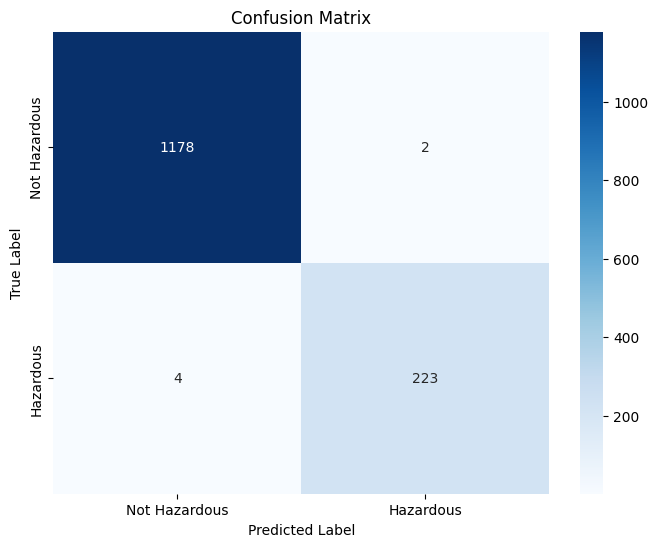

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Hazardous', 'Hazardous'],
            yticklabels=['Not Hazardous', 'Hazardous'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_test_pred)
print(report)

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1180
        True       0.99      0.98      0.99       227

    accuracy                           1.00      1407
   macro avg       0.99      0.99      0.99      1407
weighted avg       1.00      1.00      1.00      1407



This model can help scientists classify asteroids as either hazodous or non-hazardous based on the large amount of features. This model is very accurate due to the nature of extreme boosting, with an accuracy score of .99. With models like this, scientists can input data from potentially hazardous asteroids and get some information on whether or not it could be dangerous.